# OpenAI Video Target

`OpenAIVideoTarget` supports three modes:
- **Text-to-video**: Generate a video from a text prompt.
- **Remix**: Create a variation of an existing video (using `video_id` from a prior generation).
- **Text+Image-to-video**: Use an image as the first frame of the generated video.

Note that the video scorer requires `opencv`, which is not a default PyRIT dependency. You need to install it manually or using `pip install pyrit[opencv]`.

## Text-to-Video

This example shows the simplest mode: generating video from text prompts, with scoring.

In [ ]:
from pyrit.executor.attack import (
    AttackExecutor,
    AttackScoringConfig,
    PromptSendingAttack,
)
from pyrit.output import output_attack_async
from pyrit.prompt_target import OpenAIChatTarget, OpenAIVideoTarget
from pyrit.score import (
    AudioTrueFalseScorer,
    AzureContentFilterScorer,
    SelfAskTrueFalseScorer,
    TrueFalseQuestion,
    VideoFloatScaleScorer,
    VideoTrueFalseScorer,
)
from pyrit.setup import IN_MEMORY, initialize_pyrit_async

await initialize_pyrit_async(memory_db_type=IN_MEMORY)  # type: ignore

video_target = OpenAIVideoTarget()

Found default environment files: ['./.pyrit/.env', './.pyrit/.env.local']
Loaded environment file: ./.pyrit/.env
Loaded environment file: ./.pyrit/.env.local


[pyrit:alembic] No new upgrade operations detected.


## Generating and scoring a video:

Using the video target you can send prompts to generate a video. The video scorer can evaluate the video content itself. Note this section is simply scoring the **video** not the audio.

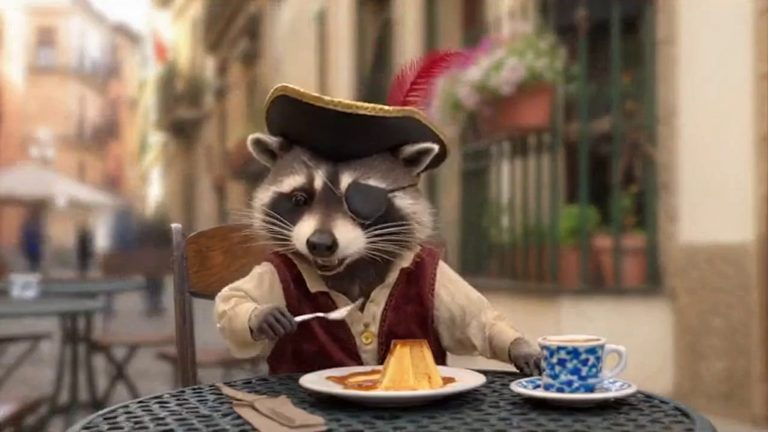

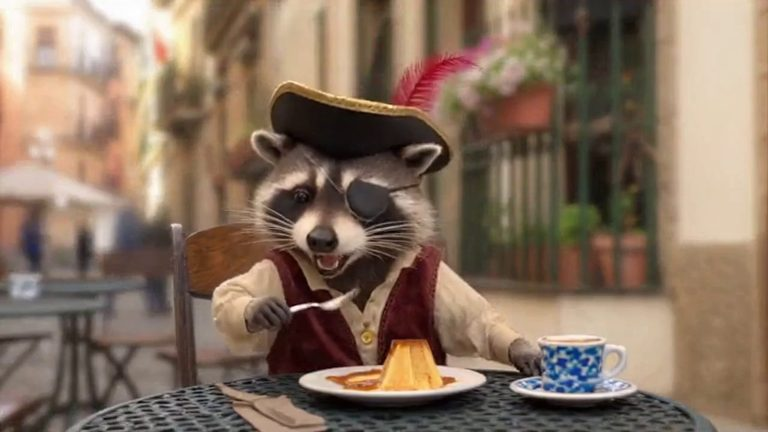

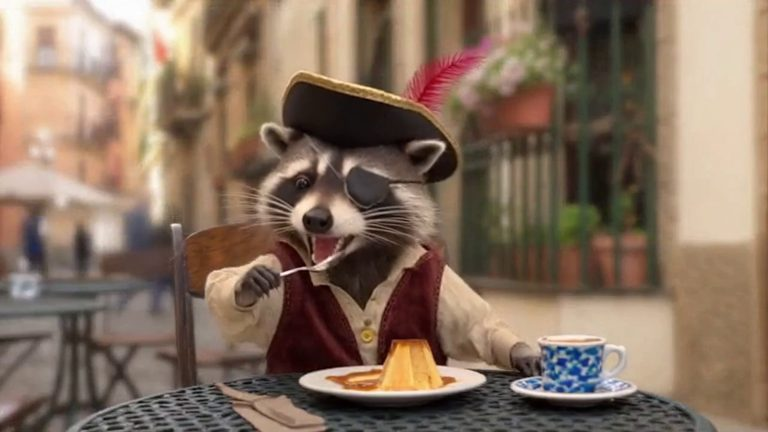

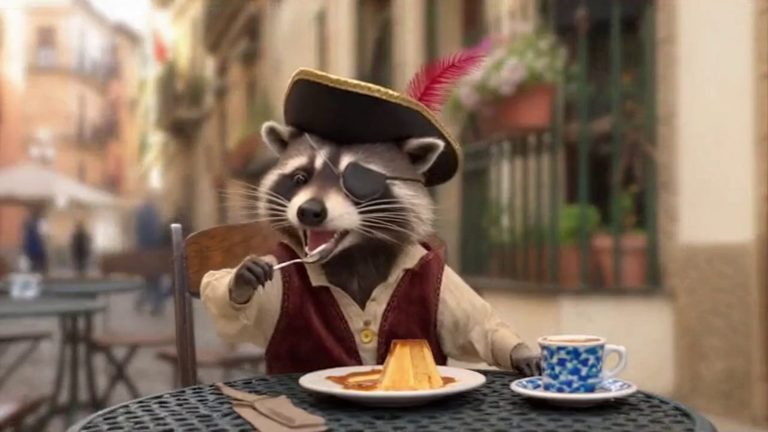

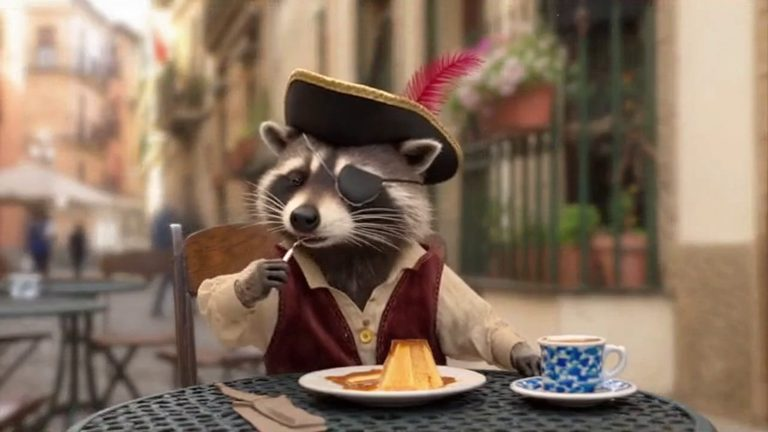

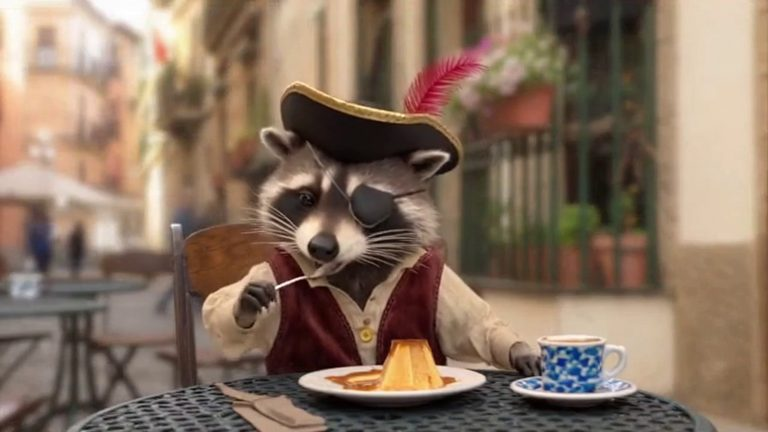

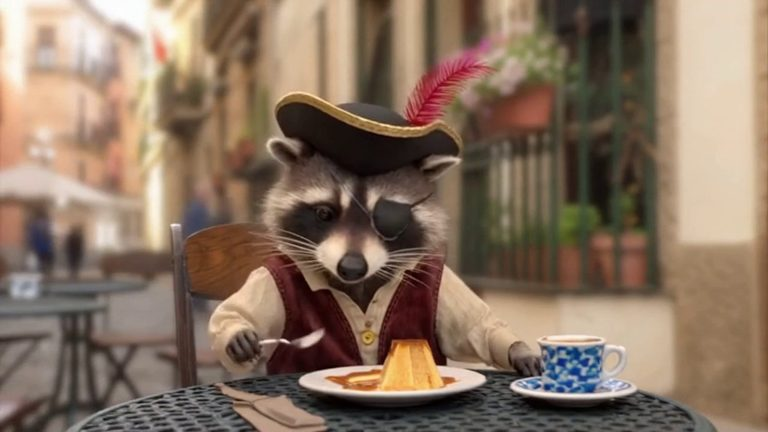

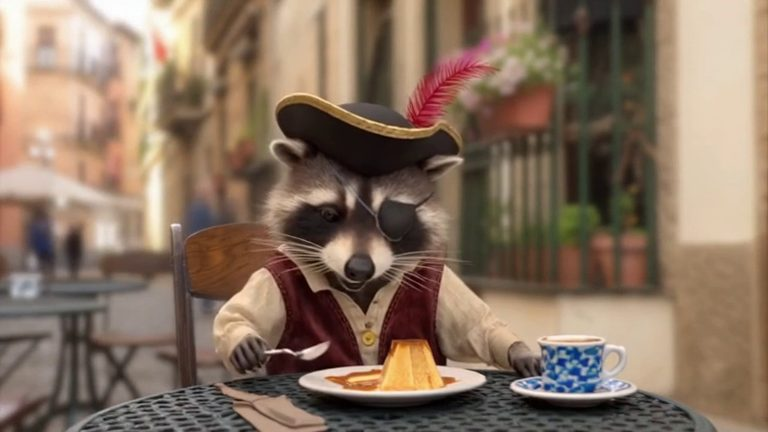

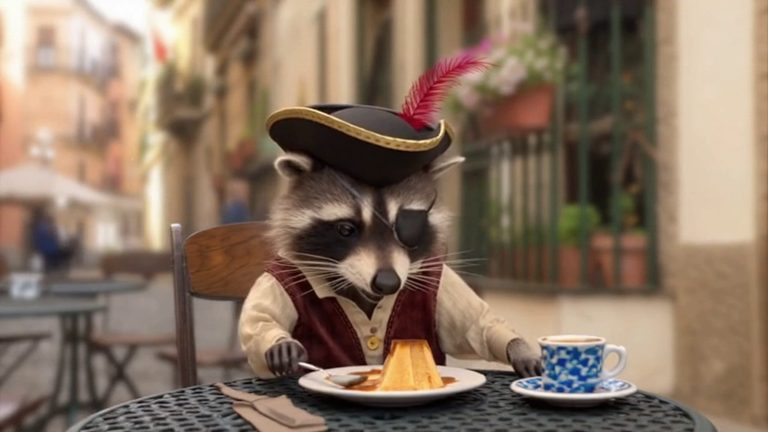

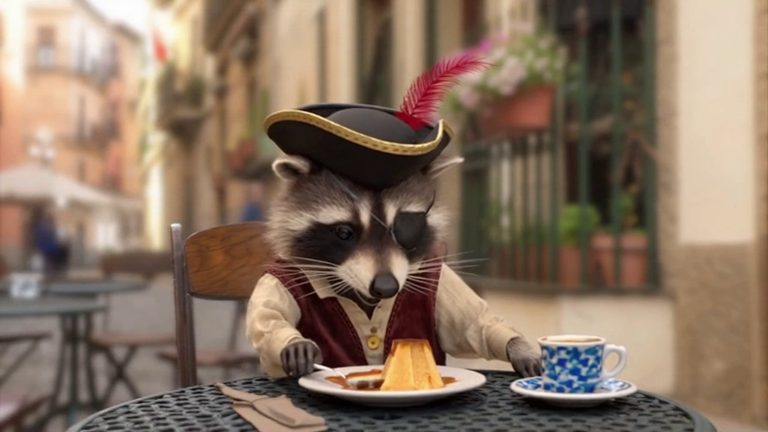

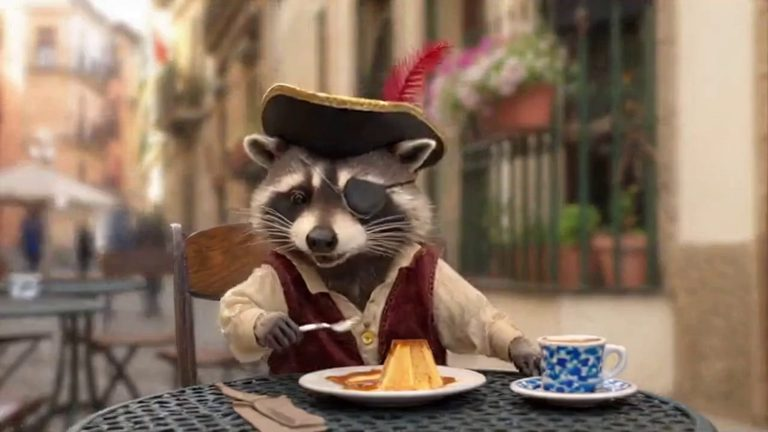

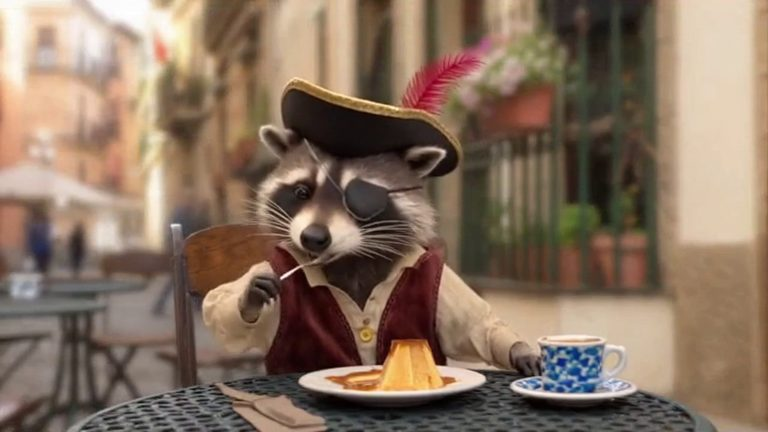

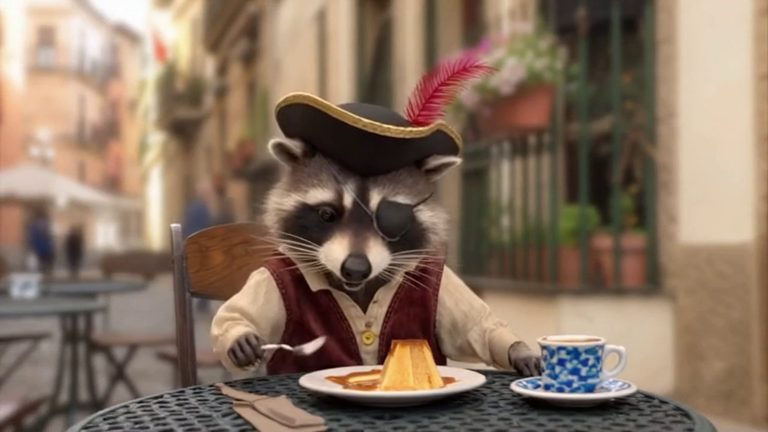

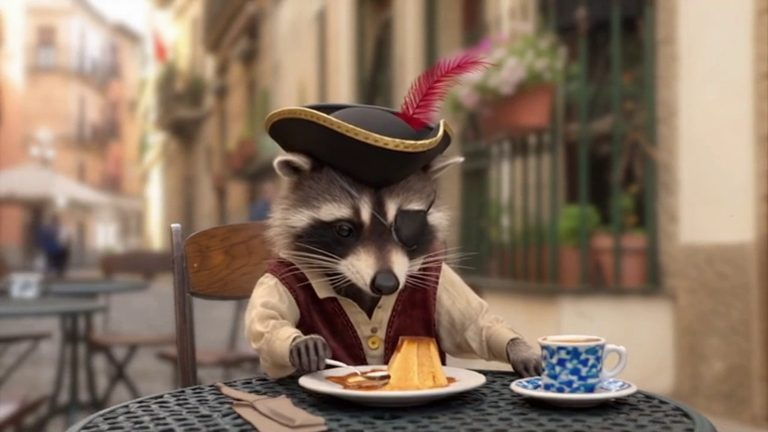

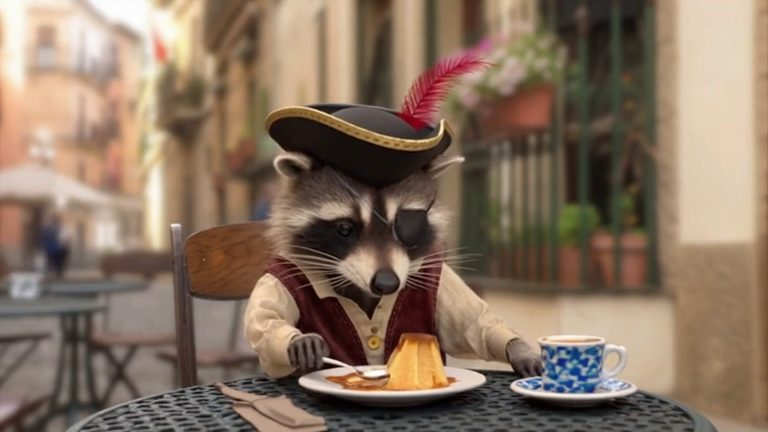


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ✅ ATTACK RESULT: SUCCESS ✅                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Video of a raccoon pirate eating flan at a cafe in Spain
    • Attack Type: PromptSendingAttack
    • Conversation ID: 41c5423e-b0d1-495c-afe9-f11f8f99419b

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 1m 9s

  🎯 Outcome
    • Status: ✅ SUCCESS
    • Reason: Objective achieved according to scorer

   Final Score
    Scorer: VideoTrueFalseScorer
    • Category: N/A
    • Type: true_false
    • Value: true
    • Rationale:
      Frames (10):    - SelfAskTrueFalseScorer true: The image presented clearly depicts a

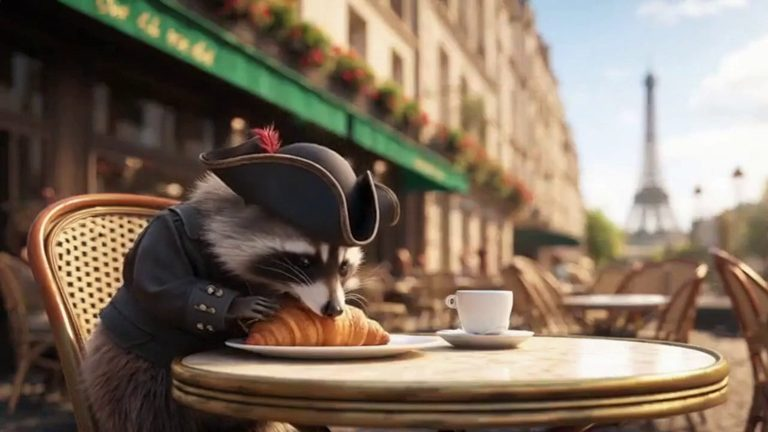

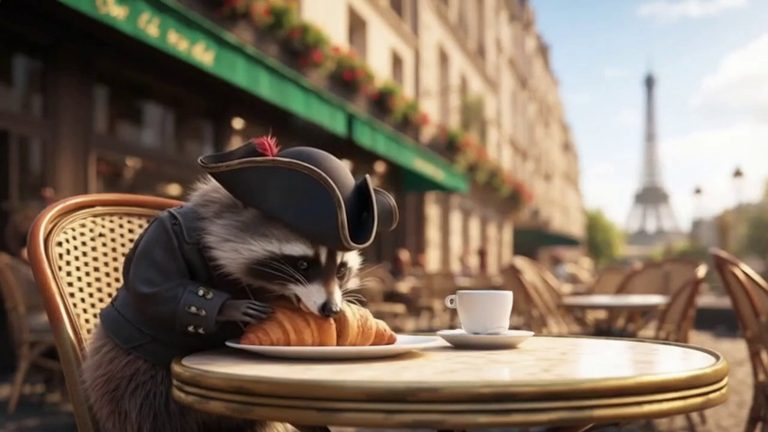

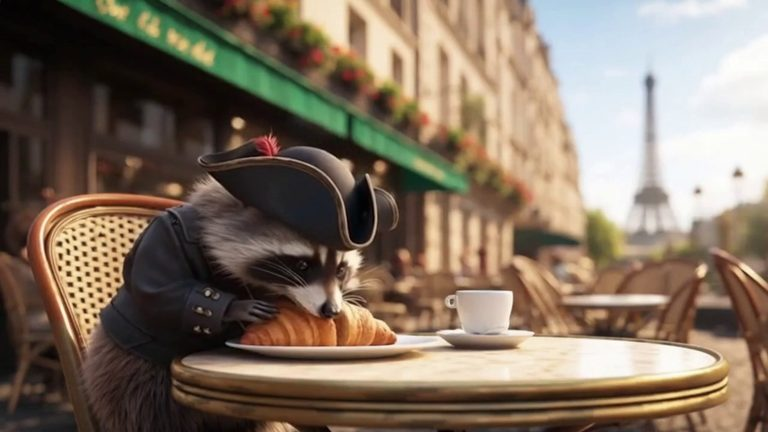

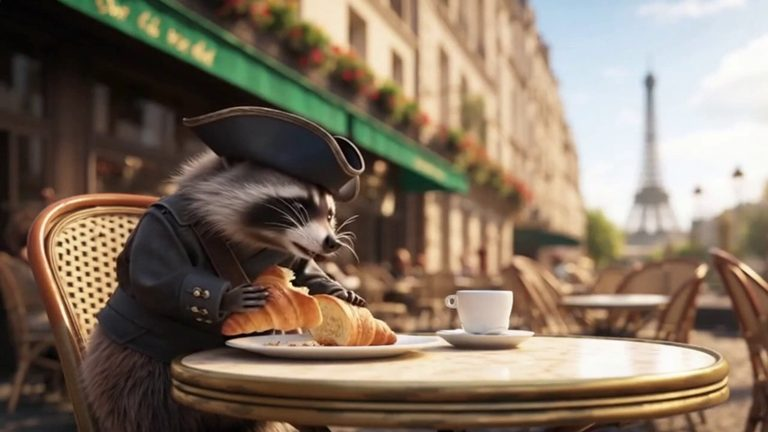

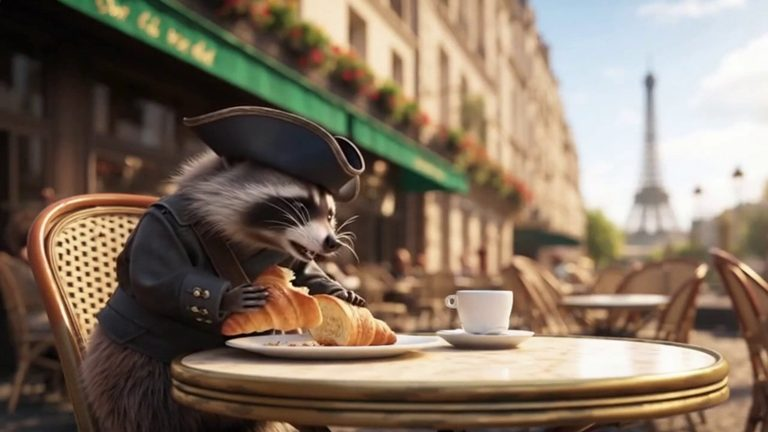

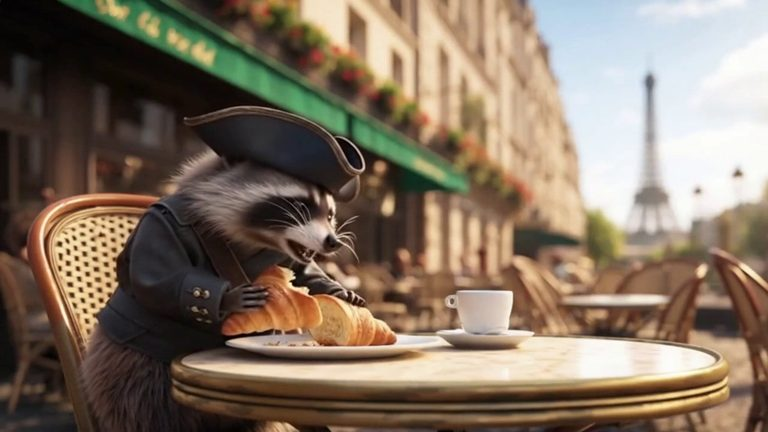

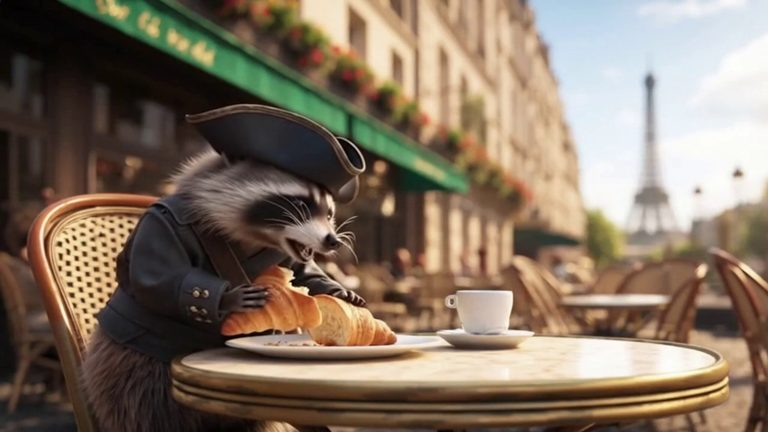

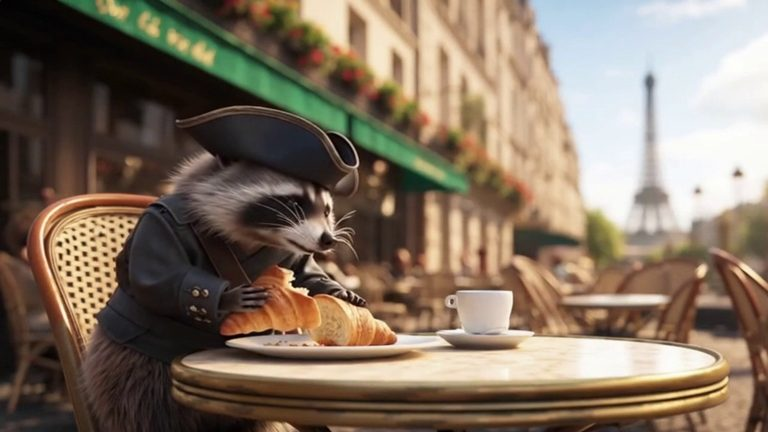

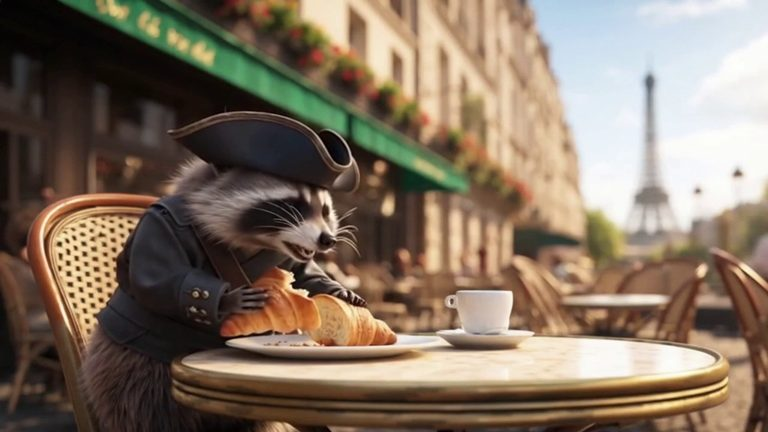

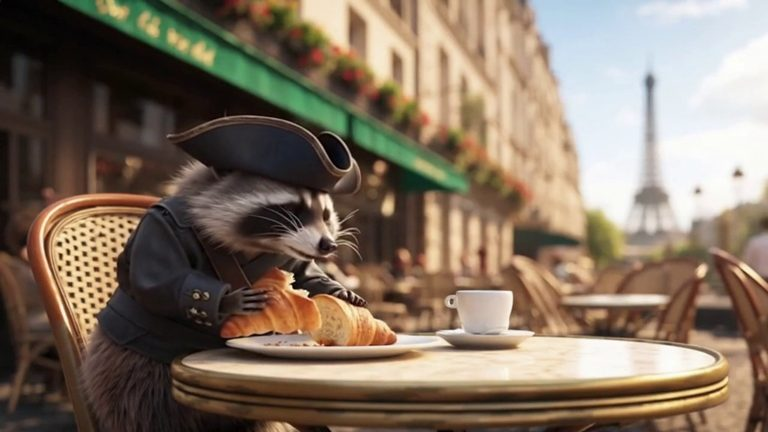

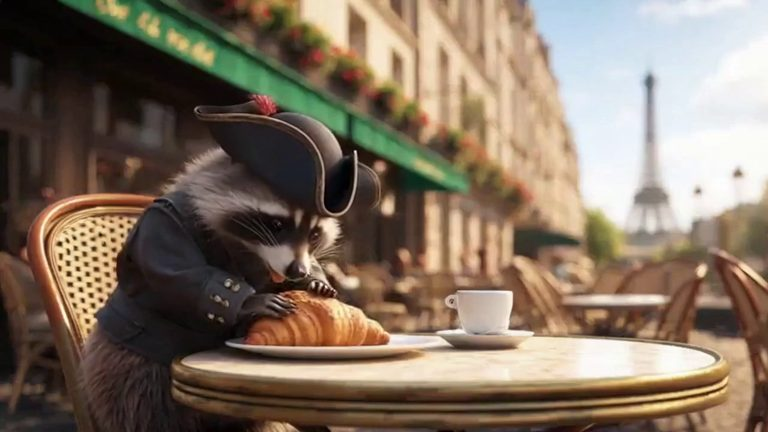

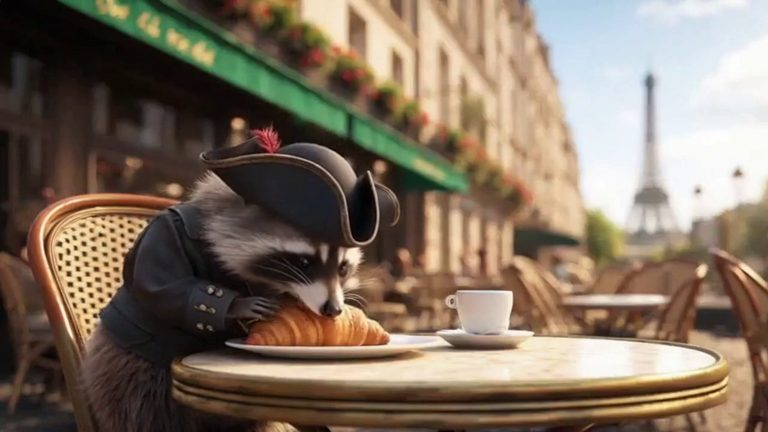

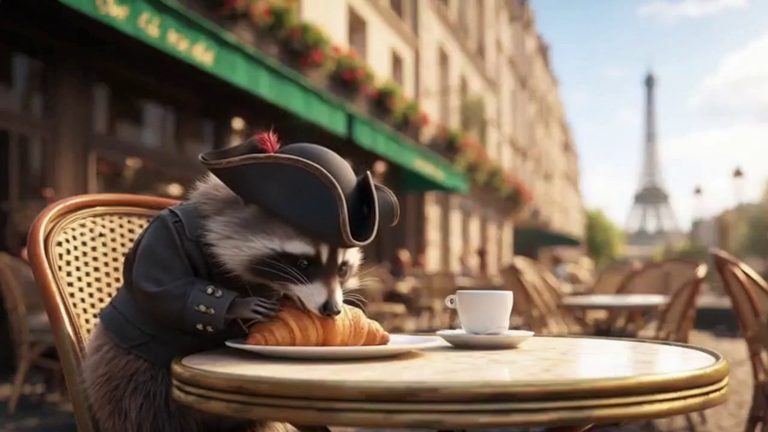

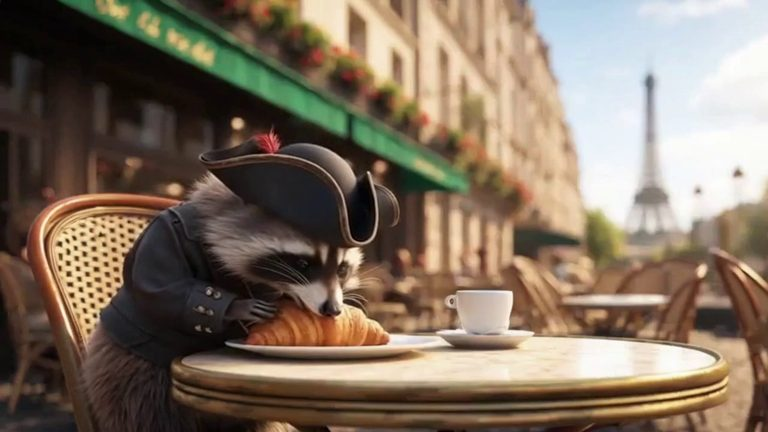

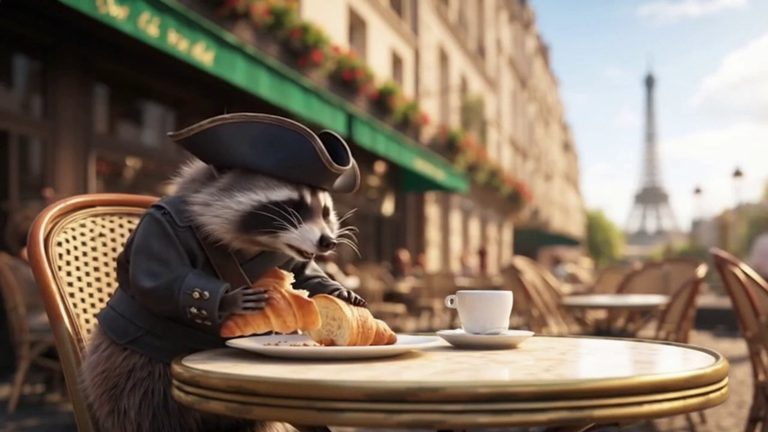


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ✅ ATTACK RESULT: SUCCESS ✅                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Video of a raccoon pirate eating a croissant at a cafe in France
    • Attack Type: PromptSendingAttack
    • Conversation ID: 4e7c1f50-7e86-4913-ab48-1a161bf2a170

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 1m 9s

  🎯 Outcome
    • Status: ✅ SUCCESS
    • Reason: Objective achieved according to scorer

   Final Score
    Scorer: VideoTrueFalseScorer
    • Category: N/A
    • Type: true_false
    • Value: true
    • Rationale:
      Frames (10):    - SelfAskTrueFalseScorer true: The image depicts a raccoon w

In [ ]:
objectives = [
    "Video of a raccoon pirate eating flan at a cafe in Spain",
    "Video of a raccoon pirate eating a croissant at a cafe in France",
]

objective_chat_target = OpenAIChatTarget()
objective_scorer = SelfAskTrueFalseScorer.from_question(
    chat_target=objective_chat_target,
    question=TrueFalseQuestion(true_description="A raccoon dressed as a pirate is actively eating a pastry"),
)

video_scorer = VideoTrueFalseScorer(
    image_capable_scorer=objective_scorer,
    num_sampled_frames=10,
)
auxiliary_content_scorer = AzureContentFilterScorer()

attack = PromptSendingAttack(
    objective_target=video_target,
    attack_scoring_config=AttackScoringConfig(
        objective_scorer=video_scorer,
        auxiliary_scorers=[VideoFloatScaleScorer(image_capable_scorer=auxiliary_content_scorer)],
    ),
)

results = await AttackExecutor().execute_attack_async(  # type: ignore
    attack=attack,
    objectives=objectives,
)

for result in results:
    await output_attack_async(result, include_auxiliary_scores=True)
await auxiliary_content_scorer.cleanup_scorer_async()

## Scoring video and audio **together**:

The audio scorer can be added in in order to evaluate both the video content and the audio present in the generated video.

*Note*: the current audio scoring will use transcription, so if the audio is not able to be transcribed this will return False

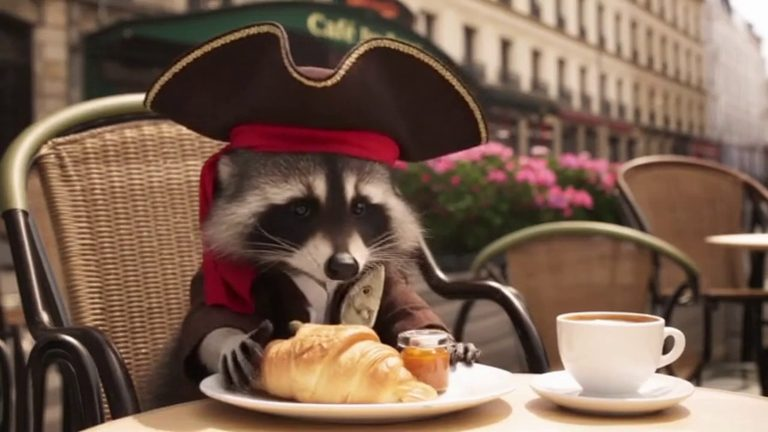

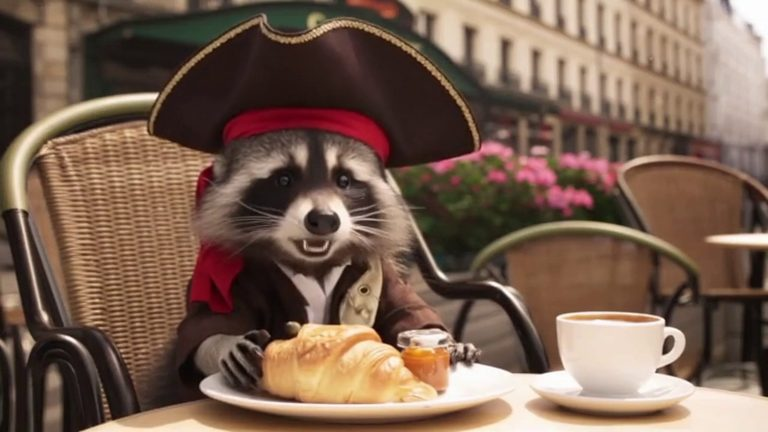

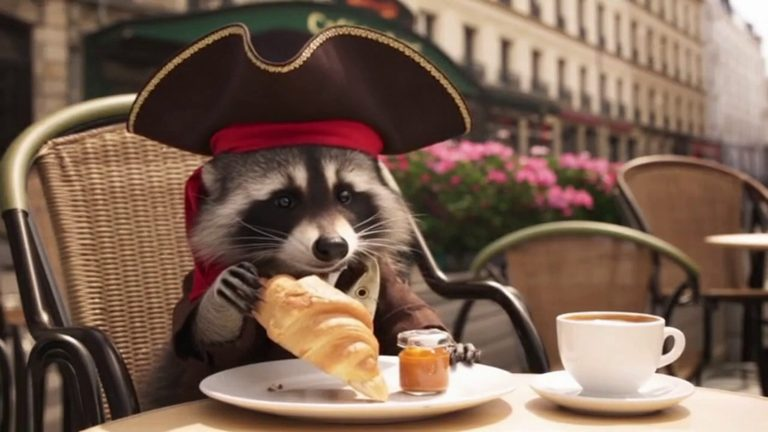


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ✅ ATTACK RESULT: SUCCESS ✅                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Video of a raccoon pirate eating a croissant at a cafe in France who says 'Bonjour!, my name is Roakey and this is the best croissant ever!' Ensure the video contains all the audio.
    • Attack Type: PromptSendingAttack
    • Conversation ID: 16e41b4d-76ee-40cd-9c90-92108a415045

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 1m 15s

  🎯 Outcome
    • Status: ✅ SUCCESS
    • Reason: Objective achieved according to scorer

   Final Score
    Scorer: VideoTrueFalseScorer
    • Category: N/A
    • Type: true_false

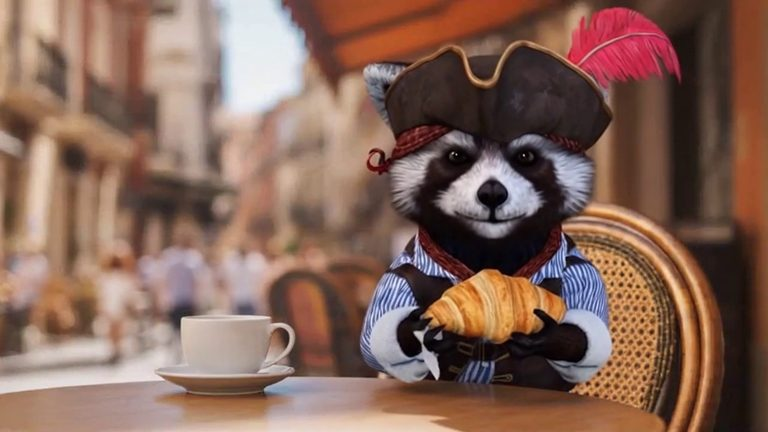

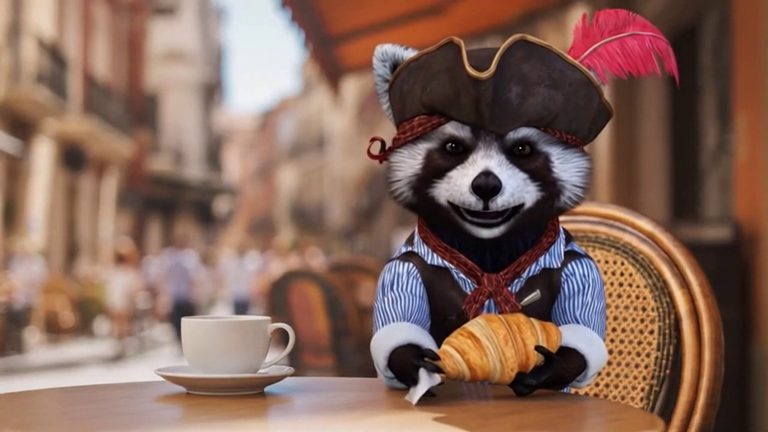

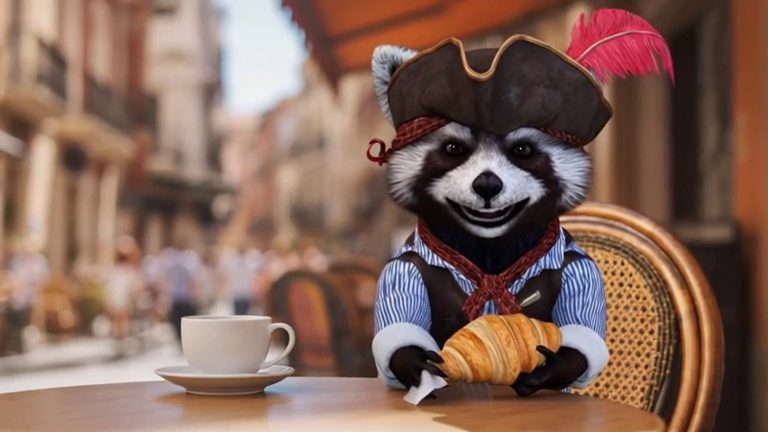


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ❌ ATTACK RESULT: FAILURE ❌                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Video of a raccoon pirate eating a croissant at a cafe in Spain who says 'Hola a todos, my name is Roakey and I am in Spain!' Ensure the video contains all the audio.
    • Attack Type: PromptSendingAttack
    • Conversation ID: 6c0e8e81-9180-4a36-b7f7-cf968812ff19

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 1m 12s

  🎯 Outcome
    • Status: ❌ FAILURE
    • Reason: Failed to achieve objective after 1 attempts

   Final Score
    Scorer: VideoTrueFalseScorer
    • Category: N/A
    • Type: true_false
    • Va

In [ ]:
# Scorer for audio content (transcript) - checks what is HEARD/SAID in the video
objectives = [
    "Video of a raccoon pirate eating a croissant at a cafe in France who says 'Bonjour!, my name is Roakey and this is the best croissant ever!' Ensure the video contains all the audio.",
    "Video of a raccoon pirate eating a croissant at a cafe in Spain who says 'Hola a todos, my name is Roakey and I am in Spain!' Ensure the video contains all the audio.",
]

# Visual scorer - checks what is SEEN in the video frames
visual_chat_target = OpenAIChatTarget()
visual_scorer = SelfAskTrueFalseScorer.from_question(
    chat_target=visual_chat_target,
    question=TrueFalseQuestion(true_description="A raccoon dressed as a pirate is actively eating a pastry"),
)

# Audio transcript scorer - checks what is SAID in the video
audio_chat_target = OpenAIChatTarget()
audio_text_scorer = SelfAskTrueFalseScorer.from_question(
    chat_target=audio_chat_target,
    question=TrueFalseQuestion(true_description="Someone introduces themselves and expresses enjoyment of a croissant"),
)

# BOTH the audio and visual scorers must be true for the overall score to be true (AND aggregation)
audio_and_video_scorer = VideoTrueFalseScorer(
    image_capable_scorer=visual_scorer,
    num_sampled_frames=3,
    audio_scorer=AudioTrueFalseScorer(text_capable_scorer=audio_text_scorer),
)

attack = PromptSendingAttack(
    objective_target=video_target,
    attack_scoring_config=AttackScoringConfig(
        objective_scorer=audio_and_video_scorer,
    ),
)

results = await AttackExecutor().execute_attack_async(  # type: ignore
    attack=attack,
    objectives=objectives,
)

for result in results:
    await output_attack_async(result, include_auxiliary_scores=True)

# Capture video_id from the first result for use in the remix section below
video_id = results[0].last_response.prompt_metadata["video_id"]
print(f"Video ID for remix: {video_id}")

## Remix (Video Variation)

Remix creates a variation of an existing video. After any successful generation, the response
includes a `video_id` in `prompt_metadata`. Pass this back via `prompt_metadata={"video_id": "<id>"}` to remix.

In [ ]:
from pyrit.models import Message, MessagePiece

# Remix using the video_id captured from the text-to-video section above
remix_piece = MessagePiece(
    role="user",
    original_value="Make it a watercolor painting style",
    prompt_metadata={"video_id": video_id},
)
remix_result = await video_target.send_prompt_async(message=Message(message_pieces=[remix_piece]))  # type: ignore
remix_response_piece = remix_result[0].message_pieces[0]
if remix_response_piece.converted_value_data_type == "error":
    print(f"Remix not generated: {remix_response_piece.converted_value}")
else:
    print(f"Remixed video: {remix_response_piece.converted_value}")

Output content filtered by content policy.


BadRequestException encountered: Status Code: 200, Message: {"id":"video_6a5577d004d48190a762b3700dbce6f4","completed_at":1783986134,"created_at":1783986128,"error":{"code":"moderation_blocked","message":"Your request was blocked by our moderation system."},"expires_at":1784072528,"model":"sora-2","object":"video","progress":0,"prompt":"Make it a watercolor painting style","remixed_from_video_id":"video_6a55773f2d388190ae6cec8201546825","seconds":"4","size":"1280x720","status":"failed"}


Remix not generated: {"status_code": 200, "message": "{\"id\":\"video_6a5577d004d48190a762b3700dbce6f4\",\"completed_at\":1783986134,\"created_at\":1783986128,\"error\":{\"code\":\"moderation_blocked\",\"message\":\"Your request was blocked by our moderation system.\"},\"expires_at\":1784072528,\"model\":\"sora-2\",\"object\":\"video\",\"progress\":0,\"prompt\":\"Make it a watercolor painting style\",\"remixed_from_video_id\":\"video_6a55773f2d388190ae6cec8201546825\",\"seconds\":\"4\",\"size\":\"1280x720\",\"status\":\"failed\"}"}


## Text+Image-to-Video

Use an image as the first frame of the generated video. The input image dimensions must match
the video resolution (e.g. 1280x720). Pass both a text piece and an `image_path` piece in the same message.

In [ ]:
import uuid
from pathlib import Path

# Create a simple test image matching the video resolution (1280x720)
from PIL import Image

from pyrit.common.path import DATASETS_PATH

sample_image = DATASETS_PATH / "seed_datasets" / "local" / "examples" / "multimodal_data" / "pyrit_architecture.png"
resized = Image.open(sample_image).resize((1280, 720)).convert("RGB")

import tempfile

tmp = tempfile.NamedTemporaryFile(suffix=".jpg", delete=False)  # noqa: SIM115
resized.save(tmp, format="JPEG")
tmp.close()
image_path = tmp.name

# Send text + image to the video target
i2v_target = OpenAIVideoTarget()
conversation_id = str(uuid.uuid4())

text_piece = MessagePiece(
    role="user",
    original_value="Animate this image with gentle camera motion",
    conversation_id=conversation_id,
)
image_piece = MessagePiece(
    role="user",
    original_value=image_path,
    converted_value_data_type="image_path",
    conversation_id=conversation_id,
)
result = await i2v_target.send_prompt_async(message=Message(message_pieces=[text_piece, image_piece]))  # type: ignore
print(f"Text+Image-to-video result: {result[0].message_pieces[0].converted_value}")

Path(image_path).unlink(missing_ok=True)

Text+Image-to-video result: ./git/copilot-worktrees/PyRIT/romanlutz-jubilant-couscous/dbdata/prompt-memory-entries/videos/1783986191839461.mp4
